In [1]:
# core function, 仔细维护
from experiment import MujocoExperiment
import numpy as np
from tqdm import tqdm
import mediapy as media
import math
import mujoco
import rootpath

# 导入root路径
import os
import sys
import os
print("Process ID:", os.getpid())
# Load the Ancestors Model
root_dir = rootpath.detect()   # 自动查找根目录

Process ID: 6884


In [2]:

path = f"{root_dir}/models/v2_4/urdf/dog2_4singleLeg_realconstrast.xml"
experiment_instance = MujocoExperiment(path)

# Model Parameter Set
stiffness_MAA, stiffness_BAA = 141.02960841103112, 113.79784850542735
l10, l20 = 0.164, 0.252
damping_MAA, damping_BAA = 24.1515, 10.3101
s1, s2 = 0.0003538647203395966, 0.0003466318012150854
c1_thigh, c2_calf = 4.9746, 0.3958
P1 = 0
P2 = 0
P1_prime = 10*1000
P2_prime = 10*1000

random_params = {
    'stiffness_MAA': stiffness_MAA,
    'stiffness_BAA': stiffness_BAA,
    'l10': l10,
    'l20': l20,
    'damping_MAA': damping_MAA,
    'damping_BAA': damping_BAA,
    's1': s1,
    's2': s2,
    'c1_thigh': c1_thigh,
    'c2_calf': c2_calf,
    'P1': P1,
    'P2': P2,
    'P1_prime': P1_prime,
    'P2_prime': P2_prime
}

# Run the Experiments
i = 0
time_step = 10
duration_exp = 20  # seconds
framerate = 60
time_sim, theta1_sim, theta2_sim, frames, _ = experiment_instance.run(random_params, time_step=time_step, duration=duration_exp)

# Save Video
# media.write_video(f"./log/video/test/experiment_output_{i}.mp4", frames, fps=framerate)

# Show the video
media.show_video(frames, fps=framerate)

# Plot Results
experiment_instance.plot_results(time_sim, theta1_sim, theta2_sim, i)

KeyboardInterrupt: 

In [ ]:
# 测试model参数: joint[-1]?
_model = mujoco.MjModel.from_xml_path(path)
_data = mujoco.MjData(_model)

In [25]:
print([_model.jnt(i).name for i in range(_model.njnt)])
print(_model.jnt(-1).name)

['RB_Shoulder', 'RB_Elbow', 'RB_MAA_UpJoint', 'RB_MAA_SlideJoint', 'RB_MAA_FM_SlideJoint', 'RB_BAA_UpJoint', 'RB_BAA_SlideJoint', 'RB_BAA_FM_SlideJoint']


IndexError: Invalid index -1. Valid indices from 0 to 7

""

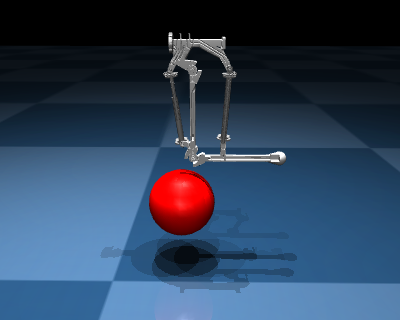

In [6]:
# Kick Ball env
path = f"{root_dir}/models/v2_4/urdf/dog2_4singleLeg_realconstrast_kickball.xml"
# Make model and data
model = mujoco.MjModel.from_xml_path(path)
data = mujoco.MjData(model)

mujoco.mj_forward(model, data)
with mujoco.Renderer(model, 320, 400) as renderer:
  renderer.update_scene(data, camera="closeup")

  media.show_image(renderer.render())

In [11]:
data.body("ball").xpos, data.body("ball").cvel[:3]

(array([ 0.12, -0.2 ,  0.2 ]), array([0., 0., 0.]))